A10 Data Visualization III Download the Iris flower dataset or any other dataset into a DataFrame. (e.g., https://archive.ics.uci.edu/ml/datasets/Iris ). Scan the dataset and give the inference as: 
1. List down the features and their types (e.g., numeric, nominal) available in the dataset.
2. Create a histogram for each feature in the dataset to illustrate the feature distributions.
3. Create a box plot for each feature in the dataset.
4. Compare distributions and identify outliers.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv(r"C:\Users\HP\Downloads\iris\iris.csv")
df.head()

,SepalLength,SepalWidth,PetalLength,PetalWidth,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [5]:
df.dtypes

SepalLength    float64
SepalWidth     float64
PetalLength    float64
PetalWidth     float64
Species         object
dtype: object

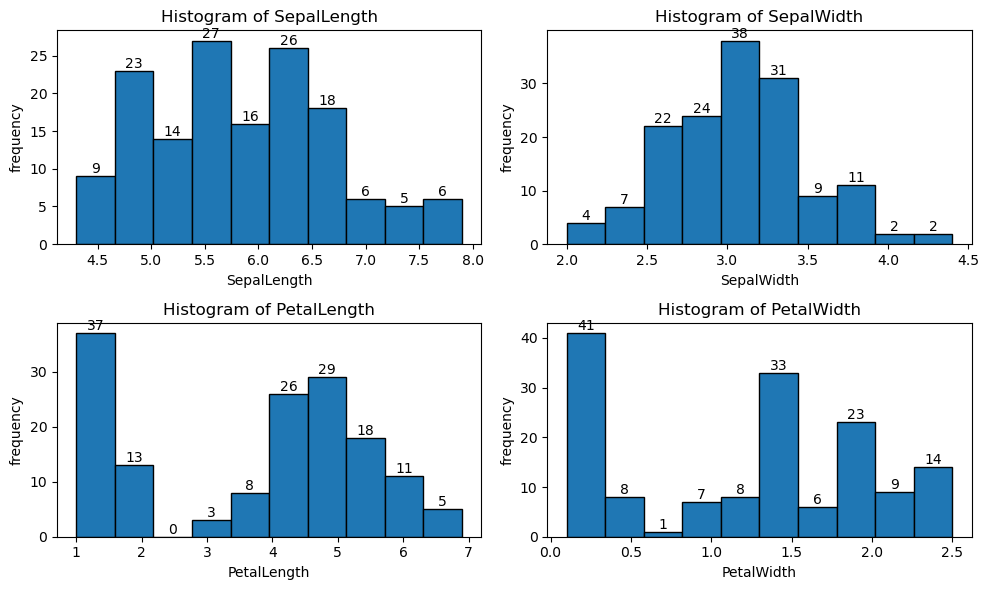

In [21]:
#Histogram for each numerical feature:
plt.figure(figsize=(10,6))

for i ,column in enumerate(df.columns[:-1]):
    plt.subplot(2,2,i+1)
    ax=plt.hist(df[column], edgecolor="black")
    plt.gca().bar_label(plt.gca().containers[0] ,fmt='%d')
    plt.title(f'Histogram of {column}')
    plt.xlabel(column)
    plt.ylabel('frequency')
plt.tight_layout()
plt.show()


array([[<Axes: title={'center': 'SepalLength'}>,
        <Axes: title={'center': 'SepalWidth'}>],
       [<Axes: title={'center': 'PetalLength'}>,
        <Axes: title={'center': 'PetalWidth'}>]], dtype=object)

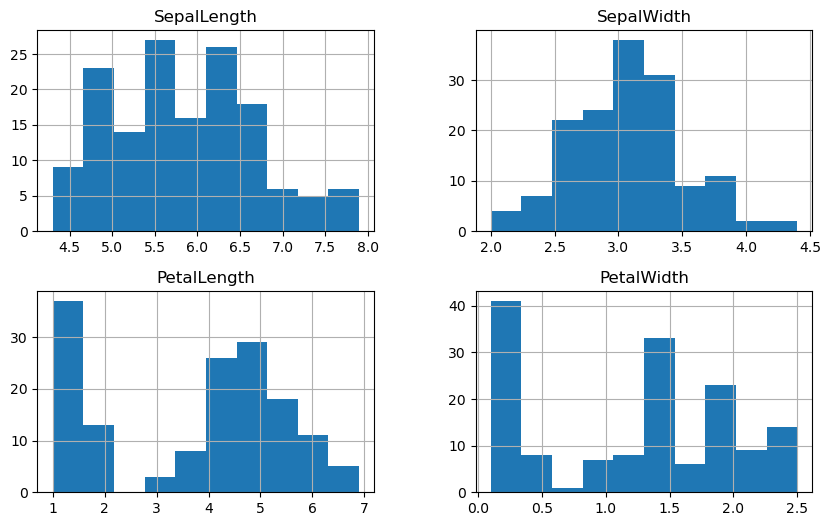

In [7]:
df.hist(figsize=(10,6))

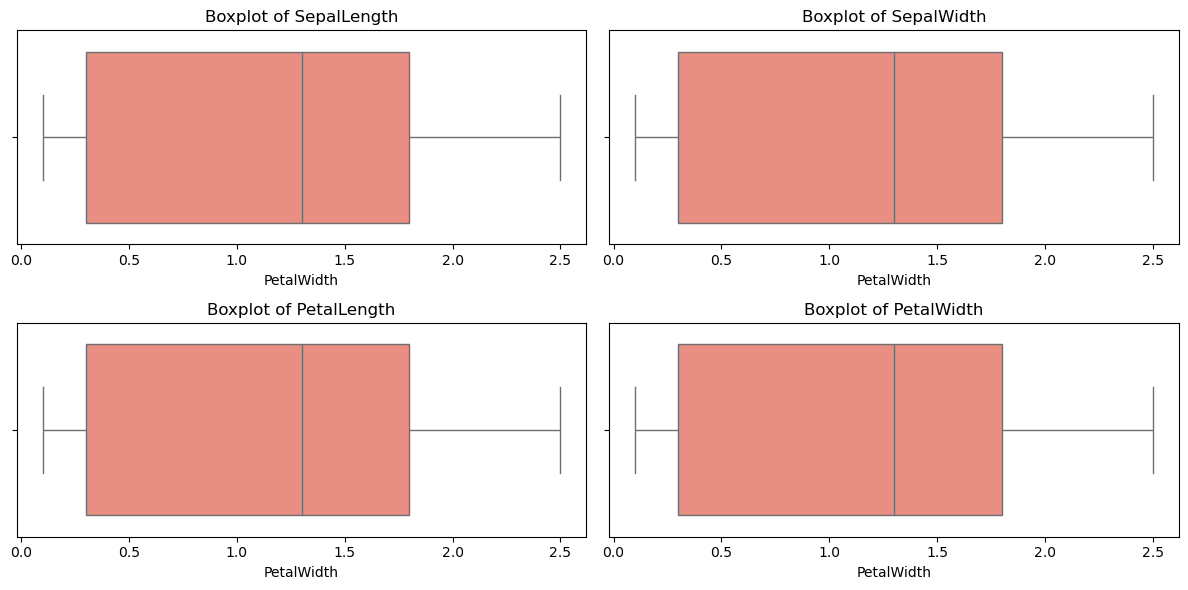

In [29]:
#boxplot for each feature 
plt.figure(figsize=(12,6))

for i,col in enumerate(df.columns[:-1]):
    ax=plt.subplot(2,2,i+1)
    box_containers=sns.boxplot(x=df[column], ax=ax, color='salmon')
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

In [23]:
#detecting outliers
for column in df.columns[:-1]:  # Exclude 'species' column
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)][column]

    print(f"\nFeature: {column}")
    print(f"  Mean: {df[column].mean():.2f}, Median: {df[column].median():.2f}, Std Dev: {df[column].std():.2f}")
    print(f"  Outliers Detected: {'Yes' if not outliers.empty else 'No'}","\n  " f"Outlier Values: {outliers.tolist()}" if not outliers.empty else "")
    print("-" * 40)


Feature: SepalLength
  Mean: 5.84, Median: 5.80, Std Dev: 0.83
  Outliers Detected: No 
----------------------------------------

Feature: SepalWidth
  Mean: 3.05, Median: 3.00, Std Dev: 0.43
  Outliers Detected: Yes 
  Outlier Values: [4.4, 4.1, 4.2, 2.0]
----------------------------------------

Feature: PetalLength
  Mean: 3.76, Median: 4.35, Std Dev: 1.76
  Outliers Detected: No 
----------------------------------------

Feature: PetalWidth
  Mean: 1.20, Median: 1.30, Std Dev: 0.76
  Outliers Detected: No 
----------------------------------------


<Axes: >

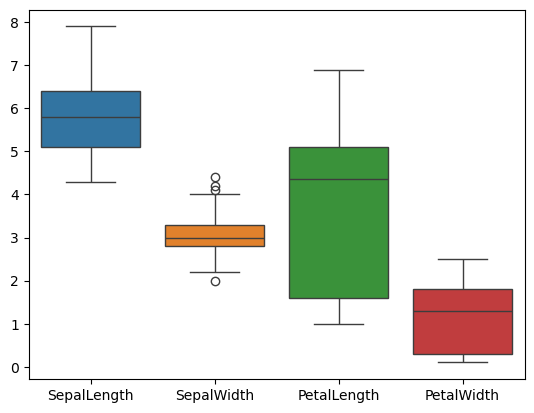

In [10]:
sns.boxplot(data=df)